In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
# Importing the food hub data
df = pd.read_csv(r"C:\Users\Abuja Office\Downloads\foodhub Data Analysis.csv")
df

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31


In [48]:
# Checking the information of the data set
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   str    
 3   cuisine_type           1898 non-null   str    
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   str    
 6   rating                 1898 non-null   str    
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 133.6 KB


In [49]:
# Checking for duplucated values
print(df.duplicated().sum())

0


In [63]:
# Type casting the string data type to category
for col in df.select_dtypes(include = "str"):
    df[col] = df[col].astype("category")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Order Id               1898 non-null   int64   
 1   Customer Id            1898 non-null   int64   
 2   Restaurant Name        1898 non-null   category
 3   Cuisine Type           1898 non-null   category
 4   Cost Of The Order      1898 non-null   float64 
 5   Day Of The Week        1898 non-null   category
 6   Rating                 1898 non-null   category
 7   Food Preparation Time  1898 non-null   int64   
 8   Delivery Time          1898 non-null   int64   
dtypes: category(4), float64(1), int64(4)
memory usage: 85.1 KB


In [112]:
# Standardizing the columns
df.columns = df.columns.str.replace("_", " ").str.title().str.strip()
df

,Restaurant Name,Cuisine Type,Cost Of The Order,Day Of The Week,Rating,Food Preparation Time,Delivery Time
0,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,Dirty Bird to Go,American,11.59,Weekday,4,25,24
...,...,...,...,...,...,...,...
1893,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,The Smile,American,12.18,Weekend,5,31,19
1895,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31


In [77]:
# Dropping unnecessary features like Id
df.drop(columns = ["Customer Id"],axis = "columns",inplace = True)

In [78]:
#1. How many rows and columns are present in the data? 
df.shape
# 1898 rows
# 9 columns

(1898, 7)

In [79]:
#2. What are the datatypes of the different columns in the dataset?
df.dtypes

Restaurant Name          category
Cuisine Type             category
Cost Of The Order         float64
Day Of The Week          category
Rating                   category
Food Preparation Time       int64
Delivery Time               int64
dtype: object

In [80]:
#3. Are there any missing values in the data? If yes, treat them using an appropriate method.
df.isnull().sum()
# There are no missing values

Restaurant Name          0
Cuisine Type             0
Cost Of The Order        0
Day Of The Week          0
Rating                   0
Food Preparation Time    0
Delivery Time            0
dtype: int64

In [85]:
#4. Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?
df.describe()
#1 Minimum time for food to be prepared = 20.000000min	
#2 Average time for food to be prepared = 27.371970min
#3 Maximum time for food to be prepared = 35.000000min

,Cost Of The Order,Food Preparation Time,Delivery Time
count,1898.000000,1898.000000,1898.000000
mean,16.498851,27.371970,24.161749
std,7.483812,4.632481,4.972637
min,4.470000,20.000000,15.000000
25%,12.080000,23.000000,20.000000
50%,14.140000,27.000000,25.000000
75%,22.297500,31.000000,28.000000
max,35.410000,35.000000,33.000000


In [82]:
#5. How many orders are not rated?
df_not = df[df["Rating"] == "Not given"]
df_not.shape[0]
# 736 orders were not rated

736

In [83]:
# 6. Explore all the variables and provide observations on their distributions.
# Checking the skweness of our data
perfect_skew = []
appro_skew = []
moderate_skew = []
high_skew = []

for col in df.select_dtypes(include = ["int64","float64"]):
    if df[col].skew() == 0:
        perfect_skew.append(col)
    elif abs(df[col].skew()) < 0.5:
        appro_skew.append(col)
    elif abs(df[col].skew()) >= 0.5 and abs(df[col].skew()) <= 1:
        moderate_skew.append(col)
    else:
        high_skew.append(col)
print(f" Perfect Skew is      :{perfect_skew}")
print(f" Approximate skew is  :{appro_skew}")
print(f" Moderate Skew is     :{moderate_skew}")
print(f" High Skew is :       {high_skew}")

 Perfect Skew is      :[]
 Approximate skew is  :['Food Preparation Time', 'Delivery Time']
 Moderate Skew is     :['Cost Of The Order']
 High Skew is :       []


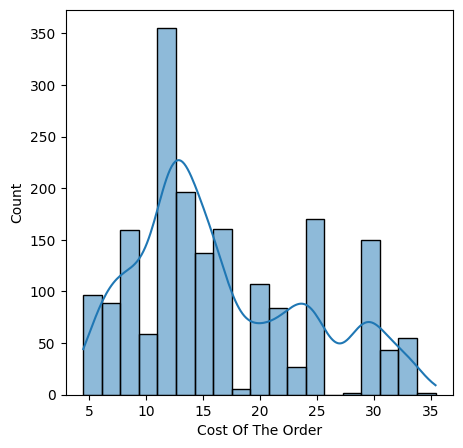

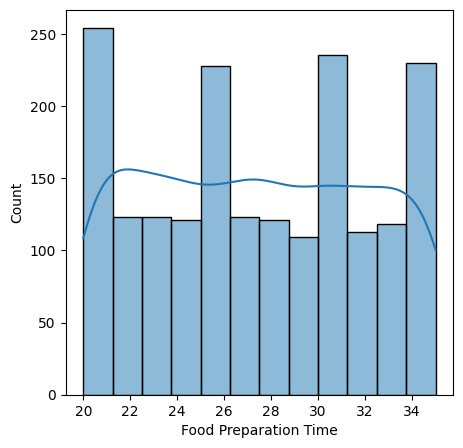

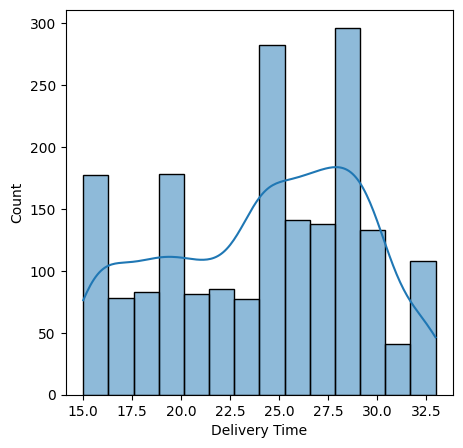

In [84]:
# Visualizing the distribution of numerical feautures using hisplot
for col in df.select_dtypes(include = ["int64","float64"]):
    plt.figure(figsize = (5,5))
    sns.histplot(data = df,x = col,kde = True)
    plt.show()
#1. The data shows that there is no perfect skew
#2. The data shows that Food Preparation Time and Delivery Time are approximated skew
#3. The data shows that ther is no high  skew

In [95]:
#7. Which are the top 5 restaurants in terms of the number of orders received?
# These are the number of orders per restaurant
restaurant_orders = df['Restaurant Name'].value_counts()
restaurant_orders
# Top five restaurants is
top5_restaurants = restaurant_orders.head(5)
print(top5_restaurants)


Restaurant Name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


In [100]:
#8. Which is the most popular cuisine on weekends?
df[df["Day Of The Week"] == "Weekend"]["Cuisine Type"].value_counts
# The most popular cusine on weekends is American

Cuisine Type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Mediterranean      32
Middle Eastern     32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64

In [108]:
#9. What percentage of the orders cost more than 20 dollars?
print((df["Cost Of The Order"] > 20).mean() * 100)
#The percentage that cost more than 20 dollars is 29.24130663856691%

29.24130663856691


In [111]:
#10. What is the mean order delivery time?
print((df["Delivery Time"].mean()))
# The percentage of delivery time is 24.161749209694417%

24.161749209694417
